# Initial Setup

In [ ]:
!pip install -q kagglehub scikit-learn pandas matplotlib seaborn imbalanced-learn xgboost

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay, f1_score,
    precision_score, recall_score, accuracy_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
#The dataset file import cell has been removed to reduce the file size. The code was the 2 lines below.
#from google.colab import files
#files.upload()

In [ ]:
CSV_PATH = "Loan_default.csv"
print("CSV_PATH:", CSV_PATH)


CSV_PATH: Loan_default.csv


# Load Dataset

In [ ]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("\nKolom:", list(df.columns))
df.head()


Shape: (255347, 18)

Kolom: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

# Exploratory Data Analysis

In [ ]:
candidate_names = ["default", "loan_status", "target", "isdefault", "class"]
TARGET_COL = None
for c in df.columns:
    if c.strip().lower() in candidate_names:
        TARGET_COL = c
        break

if TARGET_COL is None:
    for c in df.columns[::-1]:
        if df[c].dropna().nunique() == 2:
            TARGET_COL = c
            break

print("Detected target column:", TARGET_COL)

df[TARGET_COL].value_counts(normalize=True).mul(100).round(2)


Detected target column: Default


,proportion
Default,
0,88.39
1,11.61


Columns with missing value:
No missing value.


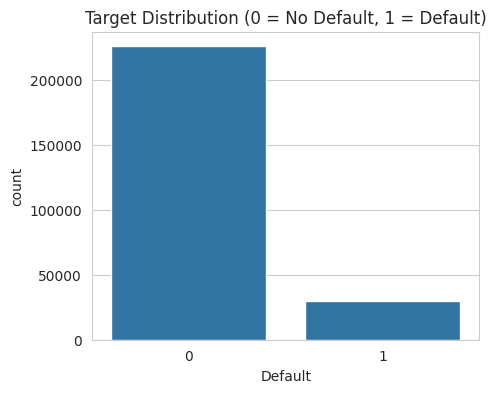

In [ ]:
# Check missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing value:")
print(missing if len(missing) else "No missing value.")

# Distribute target
plt.figure(figsize=(5,4))
sns.countplot(x=df[TARGET_COL])
plt.title("Target Distribution (0 = No Default, 1 = Default)")
plt.xlabel(TARGET_COL)
plt.show()


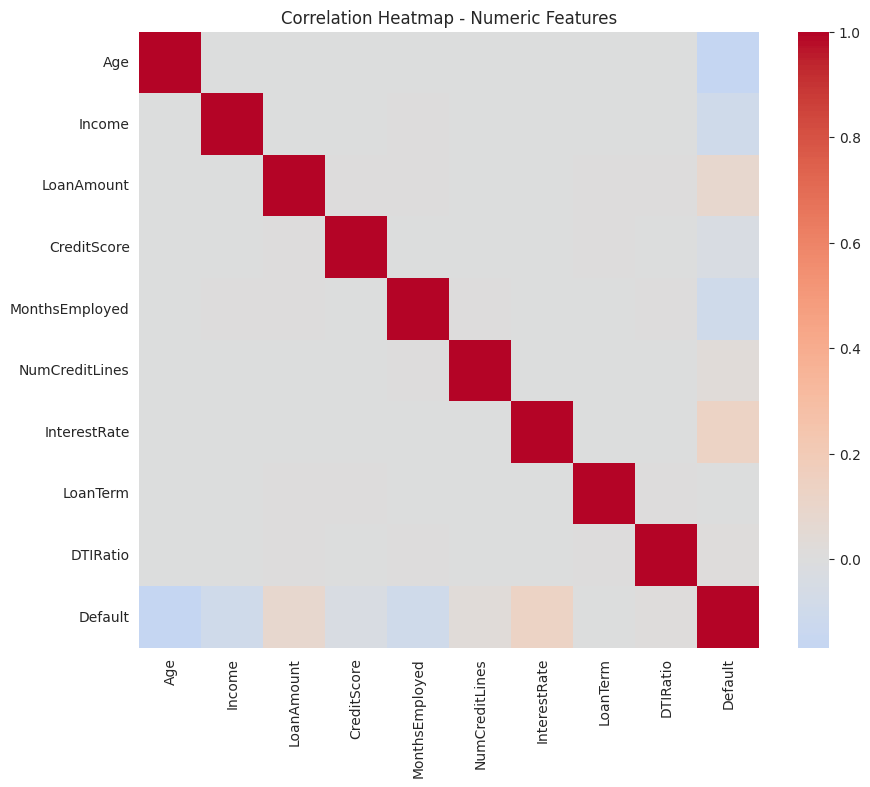

In [ ]:
# Correlation of numeric features
numeric_cols_preview = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols_preview].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()


# Preprocessing

In [ ]:
# Eliminate columns that look like ID
id_like_cols = [c for c in df.columns if df[c].nunique() == len(df) or "id" == c.strip().lower()]
print("ID columns eliminated:", id_like_cols)

feature_df = df.drop(columns=id_like_cols + [TARGET_COL])
target = df[TARGET_COL].astype(int)

numeric_features = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = feature_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)


ID columns eliminated: ['LoanID']
Numeric Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical Features: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Default proportion (train):", y_train.mean().round(4))
print("Default proportion (test):", y_test.mean().round(4))


Train shape: (204277, 16) | Test shape: (51070, 16)
Default proportion (train): 0.1161
Default proportion (test): 0.1161


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


# Logistic Regression

In [ ]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    )),
])

log_reg_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Income',
                                                   'LoanAmount', 'CreditScore',
                                                   'MonthsEmployed',
                                                   'NumCreditLines',
                                                   'InterestRate', 'LoanTerm',
                                                   'DTIRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Education',
                                                   'EmploymentType',
                                                   'MaritalStatus',
                                                   'HasMortgage',
                                                   'HasDependents',
                                                   'LoanPurpose',
                                                   'HasCoSigner'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

=== Logistic Regression (threshold=0.50) ===
              precision    recall  f1-score   support

  No Default       0.94      0.67      0.79     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070

Accuracy: 0.6764
ROC-AUC : 0.7532


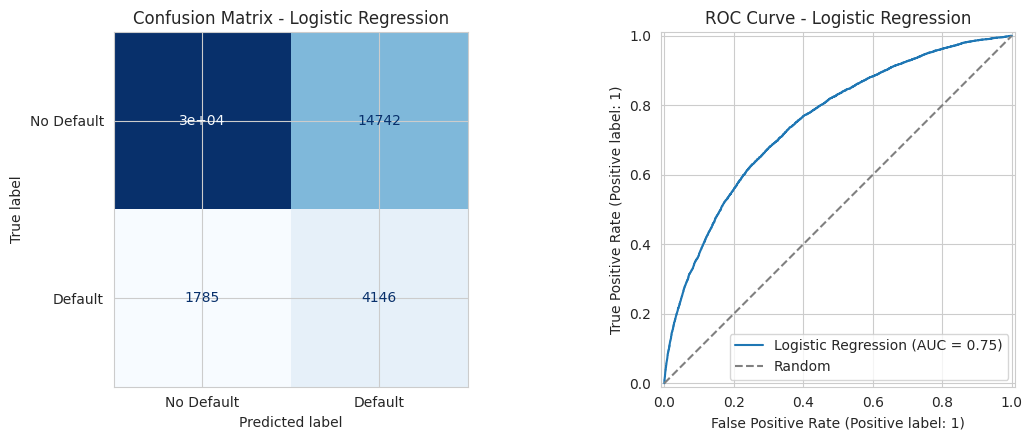

In [ ]:
def evaluate_model(pipeline, X_test, y_test, model_name, threshold=0.5):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"=== {model_name} (threshold={threshold:.2f}) ===")
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"], zero_division=0))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC : {roc_auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], cmap="Blues", colorbar=False
    )
    axes[0].set_title(f"Confusion Matrix - {model_name}")

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=model_name)
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
    axes[1].set_title(f"ROC Curve - {model_name}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "y_proba": y_proba,
    }

log_reg_results = evaluate_model(log_reg_pipeline, X_test, y_test, "Logistic Regression")


# Random Forest

In [ ]:
rf_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("resample", SMOTEENN(smote=SMOTE(random_state=RANDOM_STATE), random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])

param_dist = {
    "resample__smote__k_neighbors": [3, 5],
    "classifier__n_estimators": [150, 250, 350],
    "classifier__max_depth": [10, 16, 20, None],
    "classifier__min_samples_split": [2, 10],
    "classifier__min_samples_leaf": [1, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced_subsample"],
}

rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=6,
    scoring="f1",
    cv=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_random_search.fit(X_train, y_train)
print("Best parameter:", rf_random_search.best_params_)

rf_best_pipeline = rf_random_search.best_estimator_


Fitting 2 folds for each of 6 candidates, totalling 12 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameter: {'resample__smote__k_neighbors': 5, 'classifier__n_estimators': 150, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None, 'classifier__class_weight': 'balanced_subsample'}


=== Random Forest (threshold=0.50) ===
              precision    recall  f1-score   support

  No Default       0.93      0.82      0.87     45139
     Default       0.27      0.52      0.36      5931

    accuracy                           0.78     51070
   macro avg       0.60      0.67      0.61     51070
weighted avg       0.85      0.78      0.81     51070

Accuracy: 0.7831
ROC-AUC : 0.7488


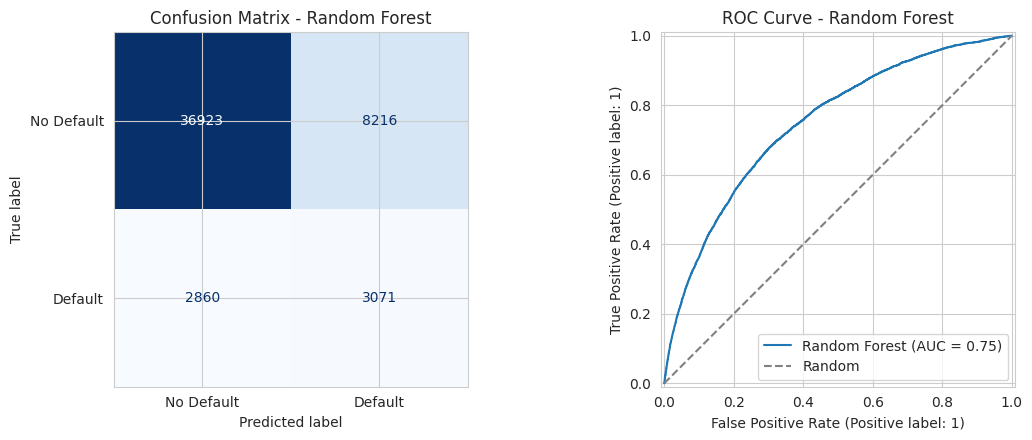

In [ ]:
rf_results = evaluate_model(rf_best_pipeline, X_test, y_test, "Random Forest")


# XGBoost

In [ ]:
xgb_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("resample", SMOTEENN(smote=SMOTE(random_state=RANDOM_STATE), random_state=RANDOM_STATE)),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_param_dist = {
    "resample__smote__k_neighbors": [3, 5],
    "classifier__n_estimators": [150, 250, 350],
    "classifier__max_depth": [3, 5, 7, 9],
    "classifier__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=6,
    scoring="f1",
    cv=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

xgb_random_search.fit(X_train, y_train)
print("Best parameter:", xgb_random_search.best_params_)

xgb_best_pipeline = xgb_random_search.best_estimator_


Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best parameter: {'resample__smote__k_neighbors': 3, 'classifier__subsample': 0.7, 'classifier__n_estimators': 350, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}


=== XGBoost (threshold=0.50) ===
              precision    recall  f1-score   support

  No Default       0.92      0.86      0.89     45139
     Default       0.31      0.46      0.37      5931

    accuracy                           0.82     51070
   macro avg       0.62      0.66      0.63     51070
weighted avg       0.85      0.82      0.83     51070

Accuracy: 0.8167
ROC-AUC : 0.7559


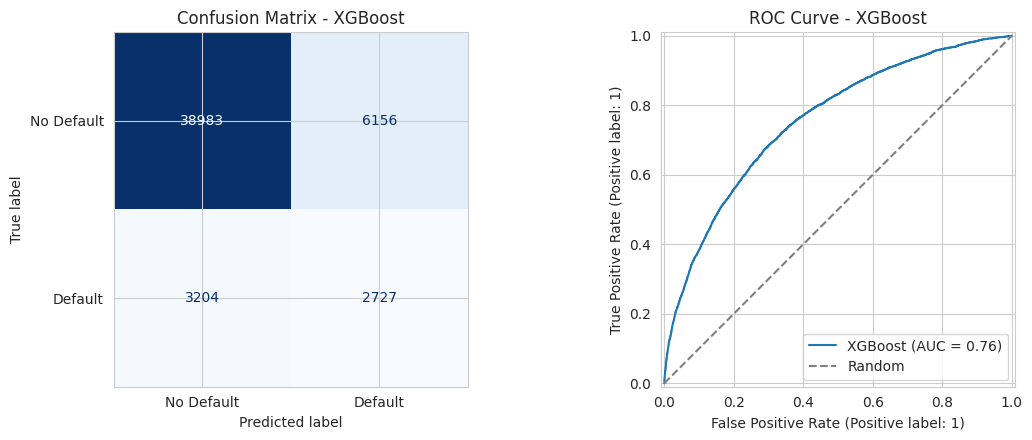

In [ ]:
xgb_results = evaluate_model(xgb_best_pipeline, X_test, y_test, "XGBoost")

# Comparison of Logistic Regression vs Random Forest vs XGBoost

In [ ]:
METRIC_COLS = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

comparison_df = pd.DataFrame([
    {k: v for k, v in log_reg_results.items() if k != "y_proba"},
    {k: v for k, v in rf_results.items() if k != "y_proba"},
    {k: v for k, v in xgb_results.items() if k != "y_proba"},
]).set_index("model")

comparison_df.style.format("{:.4f}", subset=METRIC_COLS).background_gradient(cmap="Greens", axis=0, subset=METRIC_COLS)


,threshold,accuracy,precision,recall,f1_score,roc_auc
model,,,,,,
Logistic Regression,0.500000,0.6764,0.2195,0.6990,0.3341,0.7532
Random Forest,0.500000,0.7831,0.2721,0.5178,0.3567,0.7488
XGBoost,0.500000,0.8167,0.3070,0.4598,0.3682,0.7559


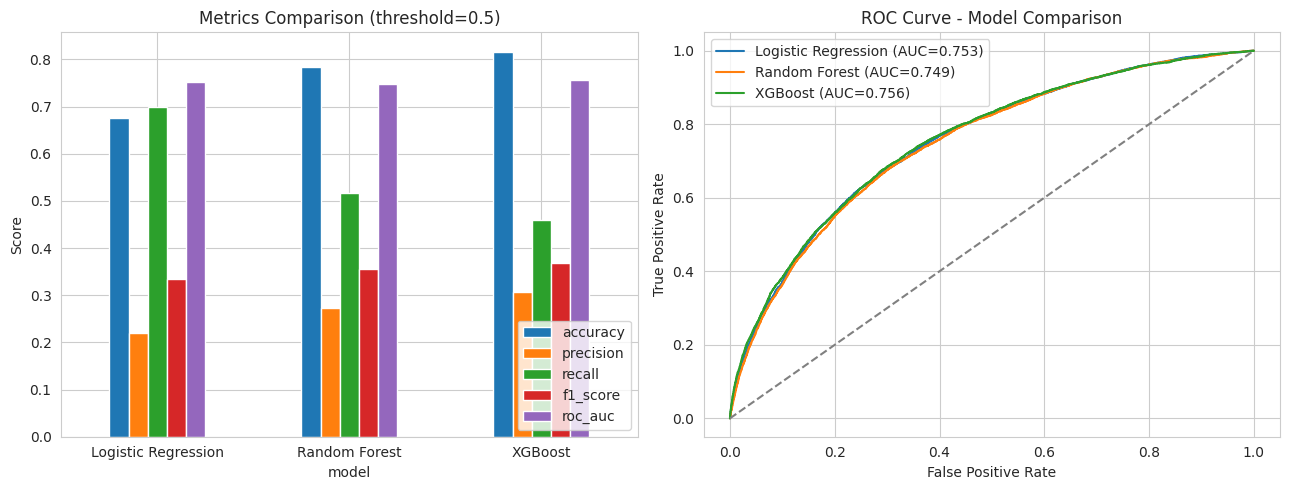

Model with highest ROC-AUC score in this run: XGBoost


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison_df[METRIC_COLS].plot(kind="bar", ax=axes[0])
axes[0].set_title("Metrics Comparison (threshold=0.5)")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")
axes[0].tick_params(axis="x", rotation=0)

fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_results["y_proba"])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_results["y_proba"])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_results["y_proba"])
axes[1].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={log_reg_results['roc_auc']:.3f})")
axes[1].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_results['roc_auc']:.3f})")
axes[1].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_results['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve - Model Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

best_model_by_auc = comparison_df["roc_auc"].idxmax()
print(f"Model with highest ROC-AUC score in this run: {best_model_by_auc}")


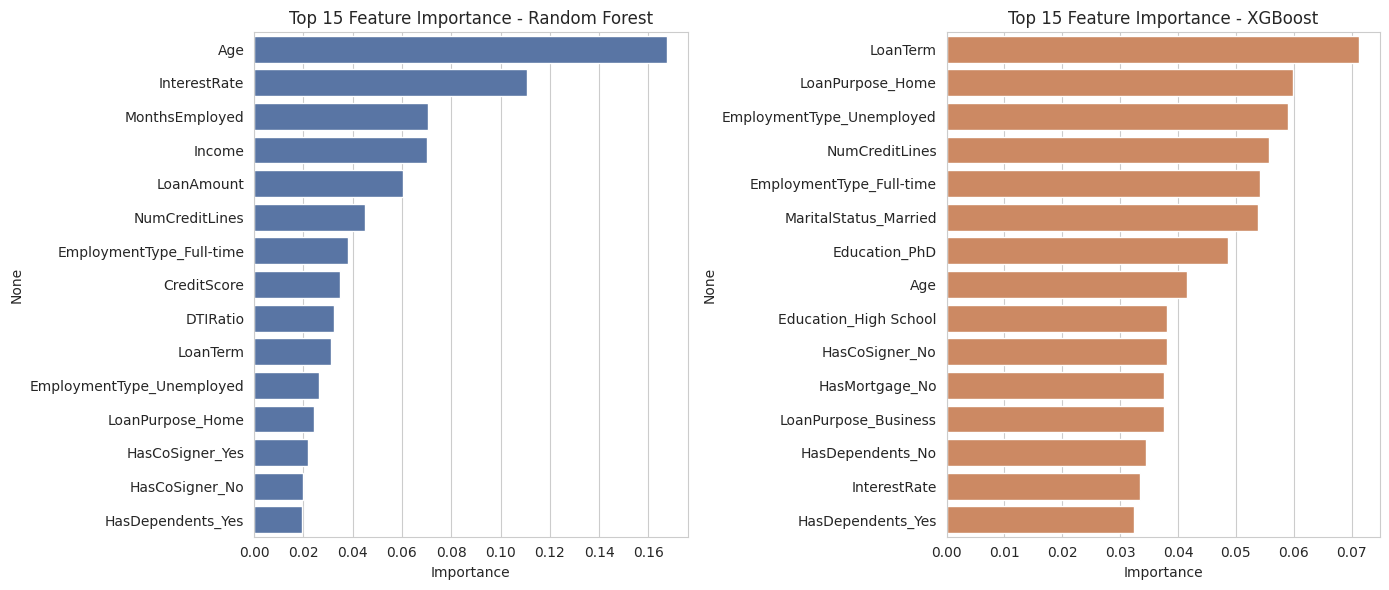

In [ ]:
# Feature importance of Random Forest & XGBoost
ohe_columns = rf_best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, ohe_columns])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importances = rf_best_pipeline.named_steps["classifier"].feature_importances_
rf_feat_imp = pd.Series(rf_importances, index=all_feature_names).sort_values(ascending=False).head(15)
sns.barplot(x=rf_feat_imp.values, y=rf_feat_imp.index, color="#4C72B0", ax=axes[0])
axes[0].set_title("Top 15 Feature Importance - Random Forest")
axes[0].set_xlabel("Importance")

xgb_importances = xgb_best_pipeline.named_steps["classifier"].feature_importances_
xgb_feat_imp = pd.Series(xgb_importances, index=all_feature_names).sort_values(ascending=False).head(15)
sns.barplot(x=xgb_feat_imp.values, y=xgb_feat_imp.index, color="#DD8452", ax=axes[1])
axes[1].set_title("Top 15 Feature Importance - XGBoost")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


# Threshold tuning

In [ ]:
def find_best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = np.divide(
        2 * precisions * recalls, precisions + recalls,
        out=np.zeros_like(precisions), where=(precisions + recalls) != 0
    )
    best_idx = np.argmax(f1_scores[:-1])  # thresholds punya panjang len(precisions)-1
    return thresholds[best_idx], f1_scores[best_idx]


lr_best_threshold, lr_best_f1 = find_best_threshold(y_test, log_reg_results["y_proba"])
rf_best_threshold, rf_best_f1 = find_best_threshold(y_test, rf_results["y_proba"])
xgb_best_threshold, xgb_best_f1 = find_best_threshold(y_test, xgb_results["y_proba"])

print(f"Logistic Regression -> optimal threshold: {lr_best_threshold:.3f} (F1={lr_best_f1:.4f})")
print(f"Random Forest       -> optimal threshold: {rf_best_threshold:.3f} (F1={rf_best_f1:.4f})")
print(f"XGBoost              -> optimal threshold: {xgb_best_threshold:.3f} (F1={xgb_best_f1:.4f})")

Logistic Regression -> optimal threshold: 0.623 (F1=0.3677)
Random Forest       -> optimal threshold: 0.529 (F1=0.3594)
XGBoost              -> optimal threshold: 0.480 (F1=0.3696)


=== Logistic Regression (tuned threshold) (threshold=0.62) ===
              precision    recall  f1-score   support

  No Default       0.93      0.83      0.88     45139
     Default       0.29      0.51      0.37      5931

    accuracy                           0.80     51070
   macro avg       0.61      0.67      0.62     51070
weighted avg       0.85      0.80      0.82     51070

Accuracy: 0.7966
ROC-AUC : 0.7532


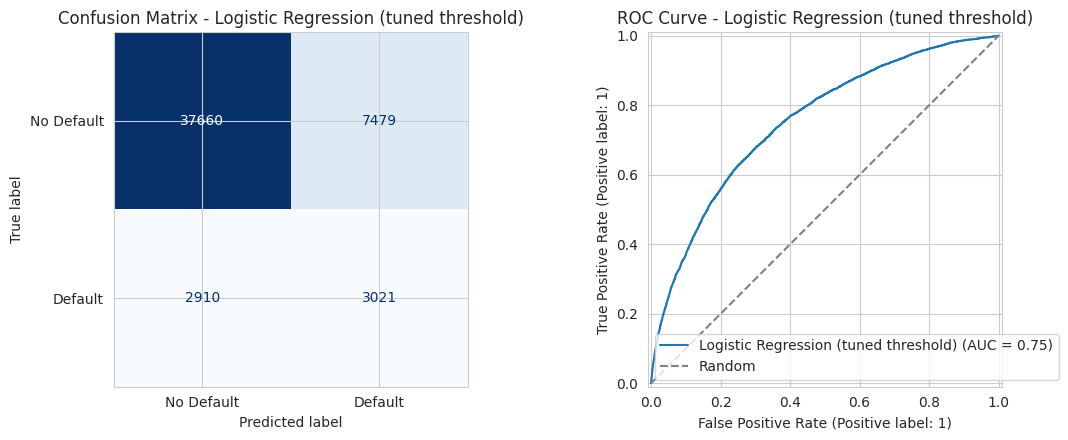

In [ ]:
log_reg_results_tuned = evaluate_model(
    log_reg_pipeline, X_test, y_test, "Logistic Regression (tuned threshold)", threshold=lr_best_threshold
)

=== Random Forest (tuned threshold) (threshold=0.53) ===
              precision    recall  f1-score   support

  No Default       0.93      0.84      0.88     45139
     Default       0.29      0.48      0.36      5931

    accuracy                           0.80     51070
   macro avg       0.61      0.66      0.62     51070
weighted avg       0.85      0.80      0.82     51070

Accuracy: 0.8008
ROC-AUC : 0.7488


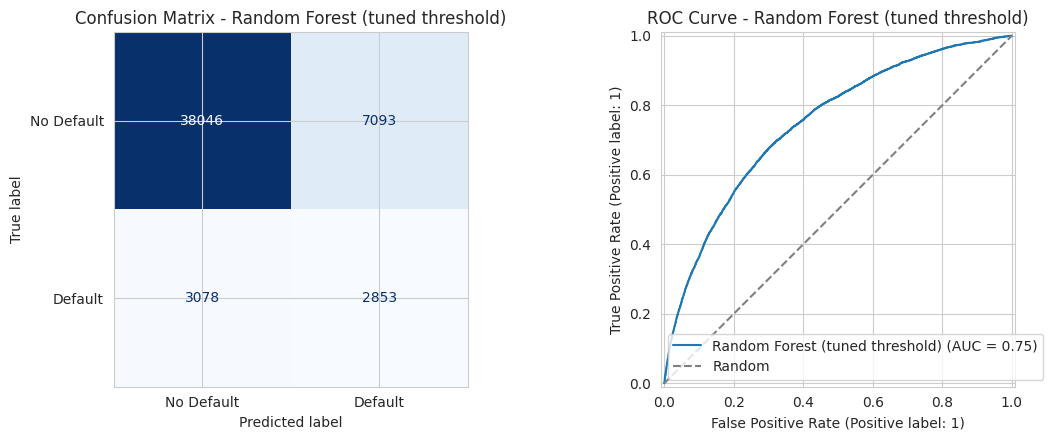

In [ ]:
rf_results_tuned = evaluate_model(
    rf_best_pipeline, X_test, y_test, "Random Forest (tuned threshold)", threshold=rf_best_threshold
)

=== XGBoost (tuned threshold) (threshold=0.48) ===
              precision    recall  f1-score   support

  No Default       0.93      0.85      0.89     45139
     Default       0.30      0.48      0.37      5931

    accuracy                           0.81     51070
   macro avg       0.61      0.67      0.63     51070
weighted avg       0.85      0.81      0.83     51070

Accuracy: 0.8088
ROC-AUC : 0.7559


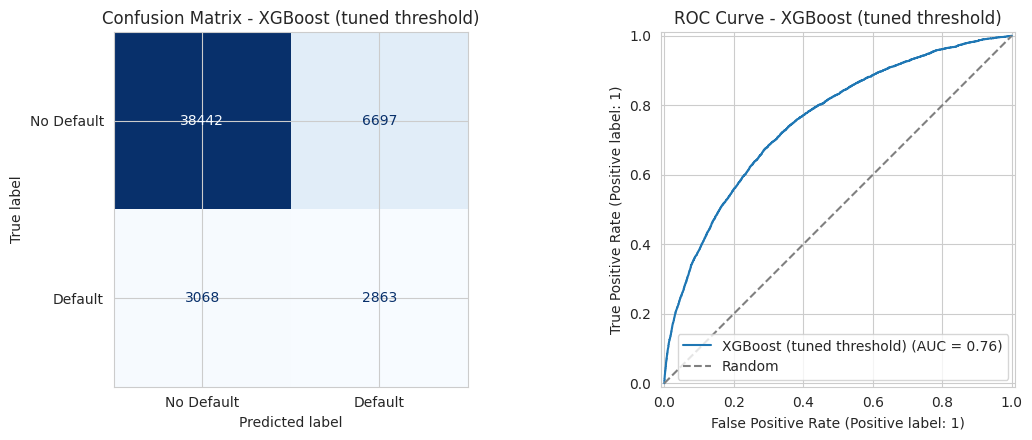

In [ ]:
xgb_results_tuned = evaluate_model(
    xgb_best_pipeline, X_test, y_test, "XGBoost (tuned threshold)", threshold=xgb_best_threshold
)

In [ ]:
comparison_df_tuned = pd.DataFrame([
    {k: v for k, v in log_reg_results_tuned.items() if k != "y_proba"},
    {k: v for k, v in rf_results_tuned.items() if k != "y_proba"},
    {k: v for k, v in xgb_results_tuned.items() if k != "y_proba"},
]).set_index("model")

print("Comparison of before vs after threshold tuning ===")
full_comparison = pd.concat([
    comparison_df.assign(stage="threshold=0.5"),
    comparison_df_tuned.assign(stage="threshold tuned"),
])
full_comparison[["stage"] + METRIC_COLS].style.format("{:.4f}", subset=METRIC_COLS)


Comparison of before vs after threshold tuning ===


,stage,accuracy,precision,recall,f1_score,roc_auc
model,,,,,,
Logistic Regression,threshold=0.5,0.6764,0.2195,0.6990,0.3341,0.7532
Random Forest,threshold=0.5,0.7831,0.2721,0.5178,0.3567,0.7488
XGBoost,threshold=0.5,0.8167,0.3070,0.4598,0.3682,0.7559
Logistic Regression (tuned threshold),threshold tuned,0.7966,0.2877,0.5094,0.3677,0.7532
Random Forest (tuned threshold),threshold tuned,0.8008,0.2868,0.4810,0.3594,0.7488
XGBoost (tuned threshold),threshold tuned,0.8088,0.2995,0.4827,0.3696,0.7559


# CalibratedClassifierCV

In [ ]:
# Select the best model after threshold tuning
candidates = {
    "Logistic Regression": (log_reg_pipeline, log_reg_results_tuned, lr_best_threshold),
    "Random Forest": (rf_best_pipeline, rf_results_tuned, rf_best_threshold),
    "XGBoost": (xgb_best_pipeline, xgb_results_tuned, xgb_best_threshold),
}

best_model_name = max(candidates, key=lambda name: candidates[name][1]["f1_score"])
best_pipeline_raw, best_results_tuned, best_threshold = candidates[best_model_name]

print(f"Best model: {best_model_name}")
print(f"F1 before calibration: {best_results_tuned['f1_score']:.4f} with threshold {best_threshold:.3f}")

calibrated_pipeline = CalibratedClassifierCV(best_pipeline_raw, method="sigmoid", cv=3)
calibrated_pipeline.fit(X_train, y_train)

Best model: XGBoost
F1 before calibration: 0.3696 with threshold 0.480


=== XGBoost (calibrated) (threshold=0.19) ===
              precision    recall  f1-score   support

  No Default       0.92      0.86      0.89     45139
     Default       0.31      0.47      0.37      5931

    accuracy                           0.82     51070
   macro avg       0.62      0.66      0.63     51070
weighted avg       0.85      0.82      0.83     51070

Accuracy: 0.8170
ROC-AUC : 0.7572


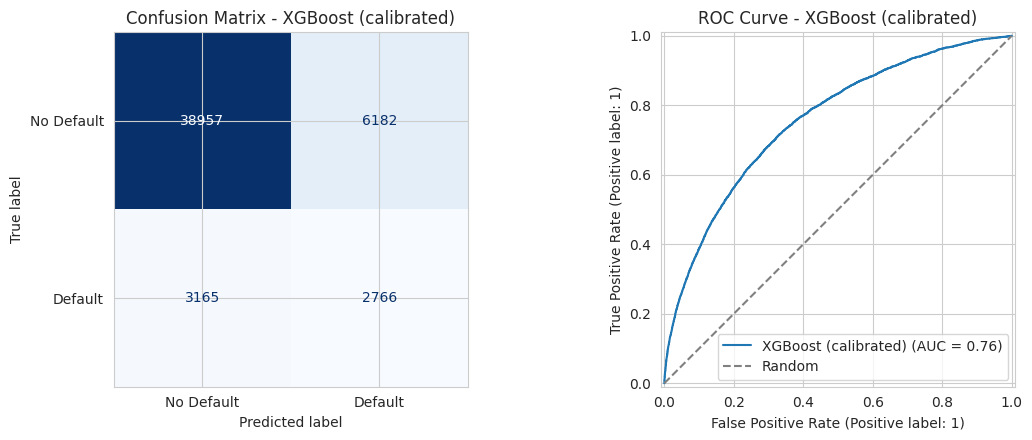

Optimal threshold after calibration: 0.190 (F1=0.3718)


In [ ]:
calibrated_proba = calibrated_pipeline.predict_proba(X_test)[:, 1]
calibrated_threshold, calibrated_f1 = find_best_threshold(y_test, calibrated_proba)

calibrated_results = evaluate_model(
    calibrated_pipeline, X_test, y_test, f"{best_model_name} (calibrated)", threshold=calibrated_threshold
)

print(f"Optimal threshold after calibration: {calibrated_threshold:.3f} (F1={calibrated_f1:.4f})")


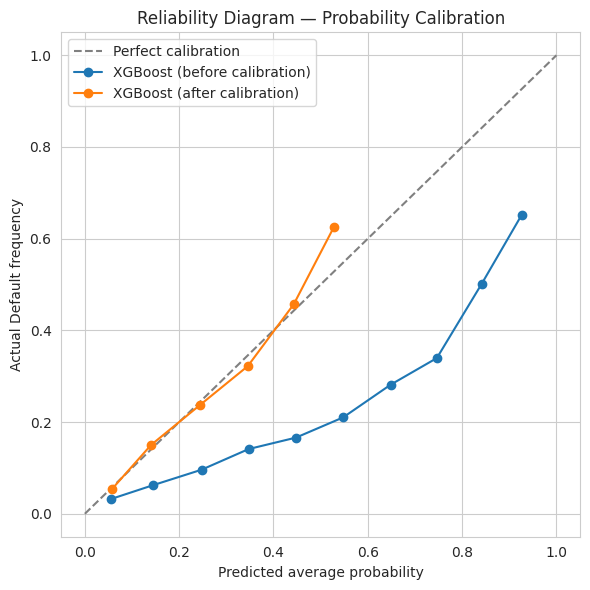

In [ ]:
# Reliability diagram (calibration curve)
from sklearn.calibration import calibration_curve

prob_true_before, prob_pred_before = calibration_curve(y_test, best_results_tuned["y_proba"], n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_test, calibrated_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(prob_pred_before, prob_true_before, marker="o", label=f"{best_model_name} (before calibration)")
plt.plot(prob_pred_after, prob_true_after, marker="o", label=f"{best_model_name} (after calibration)")
plt.xlabel("Predicted average probability")
plt.ylabel("Actual Default frequency")
plt.title("Reliability Diagram — Probability Calibration")
plt.legend()
plt.tight_layout()
plt.show()


# Best Model

In [ ]:
joblib.dump(
    {
        "pipeline": calibrated_pipeline,
        "threshold": calibrated_threshold,
        "model_name": f"{best_model_name} (calibrated)",
    },
    "loan_default_model.pkl",
)
print(f"Model '{best_model_name} (calibrated)")

best_pipeline = calibrated_pipeline
best_threshold = calibrated_threshold

Model 'XGBoost (calibrated)


In [ ]:
import hashlib

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

print("Size (bytes):", os.path.getsize("loan_default_model.pkl"))
print("SHA256:", sha256_of("loan_default_model.pkl"))

Size (bytes): 296473555
SHA256: b65f4e8cec53e63d958fd91ab9733aa4e65a38d256bf81baee4d3ad8ef506a7e


In [ ]:
#Download pkl file
from google.colab import files
files.download("loan_default_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>